

```
# This is formatted as code
```

*Name-Shantanu Kaute  | PRN -1252090007 | Roll no-07



11. Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

Accuracy: 0.9125

Confusion Matrix:
 [[ 5  5]
 [ 2 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.50      0.59        10
           1       0.93      0.97      0.95        70

    accuracy                           0.91        80
   macro avg       0.82      0.74      0.77  

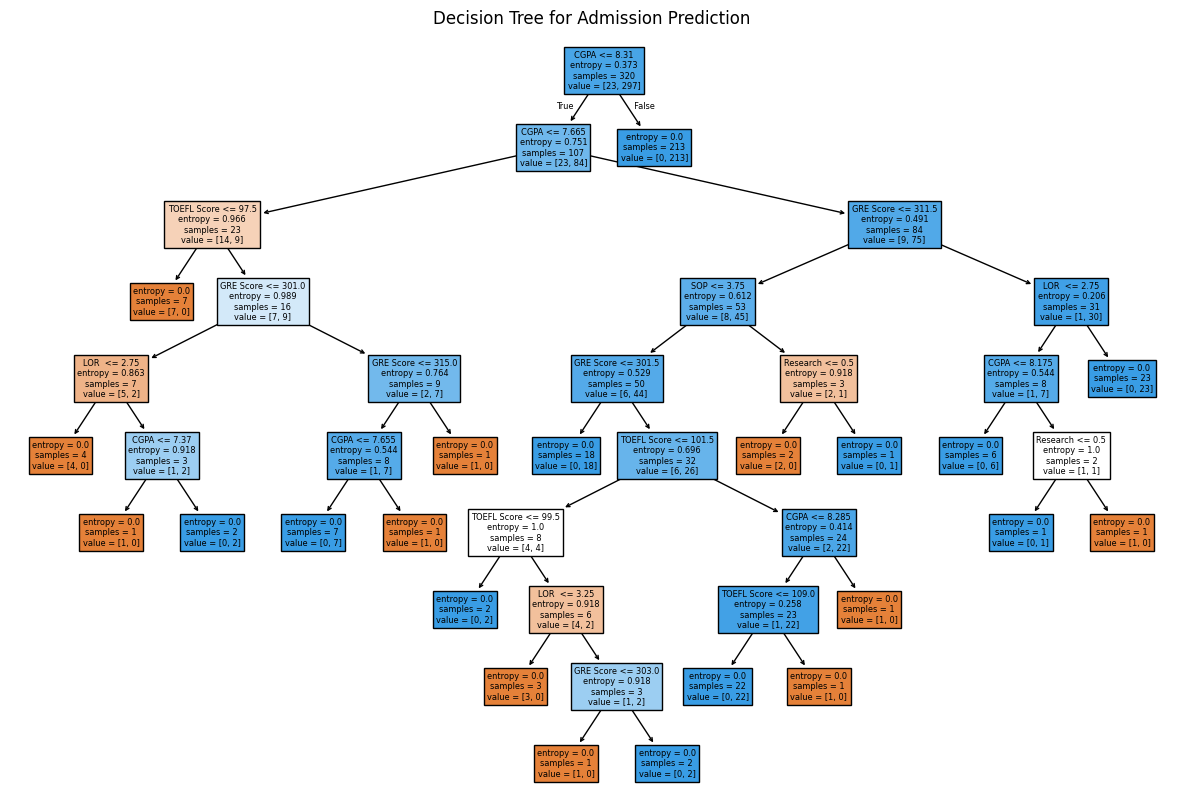

In [ ]:

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
data = pd.read_csv("Admission_Predict.csv")

print(data.head())

# Data Preprocessing
# Remove Serial No column if present
if 'Serial No.' in data.columns:
    data = data.drop('Serial No.', axis=1)

# Convert chance of admit into binary (0 or 1)
# If dataset contains "Chance of Admit"
if 'Chance of Admit ' in data.columns:
    data['Admitted'] = (data['Chance of Admit '] >= 0.5).astype(int)
    data = data.drop('Chance of Admit ', axis=1)

# Features and Target
X = data.drop('Admitted', axis=1)
y = data['Admitted']


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Decision Tree Model
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)


# Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.title("Decision Tree for Admission Prediction")
plt.show()